In [62]:
EXP_DIR="../results/framework_validation_0827"

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class CustPalette:
  primary_dark="#262699"
  primary="#2945ad"
  primary_med="#6882db"
  primary_light="#a9b9f0"
  primary_x_light="#d7e0ff"
  secondary="#ff3477"
  secondary_light="#ff84ad"
  secondary_x_light="#ffb4cd"
  tertiary="#26cc90"
  grey_light='#cbd5e1'
  grey_med='#727B8D'
  grey_dark='#17191C'
  green='#5fdf50'

In [64]:
results_df = pd.read_csv(f"{EXP_DIR}/benchmark_results.csv")
# datasets_df = pd.read_csv(f"{EXP_DIR}/benchmark_datasets.csv")

optuna_mask = results_df['optimiser'] == 'optuna'
llm_mask = results_df['optimiser'] == 'llm'

In [65]:
results_df.columns

Index(['run_id', 'status', 'start_time', 'end_time', 's_prev', 'max_retries',
       'y_prev', 'target_ppv_disp', 'disp_tolerance', 'seed',
       'target_recall_disp', 'y_prev_base_ratio', 'dataset_id', 'target_disp',
       'optimiser', 'target_auprc', 'downstream_mlp_ppv_disp_std',
       'raw_gen_converged', 'auprc', 'downstream_rf_auprc_std',
       'downstream_lr_recall_disp_mean', 'downstream_mlp_auprc_mean',
       'downstream_rf_recall_disp_std', 'recall_disp',
       'downstream_mlp_recall_disp_std', 'downstream_mlp_ppv_disp_mean',
       'retry_count', 'bias_converged', 'input_tokens',
       'downstream_rf_ppv_disp_std', 'downstream_rf_recall_disp_mean',
       'downstream_rf_auprc_mean', 'downstream_rf_ppv_disp_mean',
       'downstream_mlp_recall_disp_mean', 'output_tokens',
       'downstream_mlp_auprc_std', 'raw_gen_trials',
       'downstream_lr_ppv_disp_mean', 'downstream_lr_auprc_std',
       'downstream_lr_recall_disp_std', 'downstream_lr_auprc_mean',
       'downst

# Success Rates

## AUPRC Target

In [66]:
# Convergence after Raw Generation
optuna_raw_gen_conv_n = results_df.loc[optuna_mask, 'raw_gen_converged'].sum()
llm_raw_gen_conv_n = results_df.loc[llm_mask, 'raw_gen_converged'].sum()

print(f"OPTUNA: Number of converged raw generations: {optuna_raw_gen_conv_n} ({optuna_raw_gen_conv_n / len(results_df[optuna_mask]) * 100:.2f}%)")
print(f"LLM: Number of converged raw generations: {llm_raw_gen_conv_n} ({llm_raw_gen_conv_n / len(results_df[llm_mask]) * 100:.2f}%)")

OPTUNA: Number of converged raw generations: 94.0 (97.92%)
LLM: Number of converged raw generations: 96.0 (100.00%)


In [67]:
# Final Convergence
results_df['target_auprc_met'] = results_df['target_auprc'] <= results_df['auprc']

unique_auprc_targets = results_df['target_auprc'].unique()
for (optimiser, target), group in results_df.groupby(['optimiser','target_auprc']):
  print(f"\n==== {optimiser.upper()}, TARGET = {target*100}% ====")
  unmet_auprc_target = group[~group['target_auprc_met']]
  missed_n = len(unmet_auprc_target)
  print(f"Missed target in {missed_n} datasets out of {len(group)} ({missed_n / len(group) * 100:.2f}%)")
  auprc_discr = unmet_auprc_target['target_auprc'] - unmet_auprc_target['auprc']
  average_auprc_discr = auprc_discr.mean()
  max_auprc_discr = auprc_discr.max()

  print(f"Average AUPRC discrepancy when target is missed: {average_auprc_discr*100:.2f}%")
  print(f"Maximum AUPRC discrepancy when target is missed: {max_auprc_discr*100:.2f}%")


==== LLM, TARGET = 50.0% ====
Missed target in 7 datasets out of 42 (16.67%)
Average AUPRC discrepancy when target is missed: 1.86%
Maximum AUPRC discrepancy when target is missed: 3.53%

==== LLM, TARGET = 65.0% ====
Missed target in 1 datasets out of 12 (8.33%)
Average AUPRC discrepancy when target is missed: 0.25%
Maximum AUPRC discrepancy when target is missed: 0.25%

==== LLM, TARGET = 90.0% ====
Missed target in 14 datasets out of 42 (33.33%)
Average AUPRC discrepancy when target is missed: 0.56%
Maximum AUPRC discrepancy when target is missed: 1.42%

==== OPTUNA, TARGET = 50.0% ====
Missed target in 9 datasets out of 42 (21.43%)
Average AUPRC discrepancy when target is missed: 2.74%
Maximum AUPRC discrepancy when target is missed: 6.06%

==== OPTUNA, TARGET = 65.0% ====
Missed target in 5 datasets out of 12 (41.67%)
Average AUPRC discrepancy when target is missed: 5.01%
Maximum AUPRC discrepancy when target is missed: 7.61%

==== OPTUNA, TARGET = 90.0% ====
Missed target in 15 

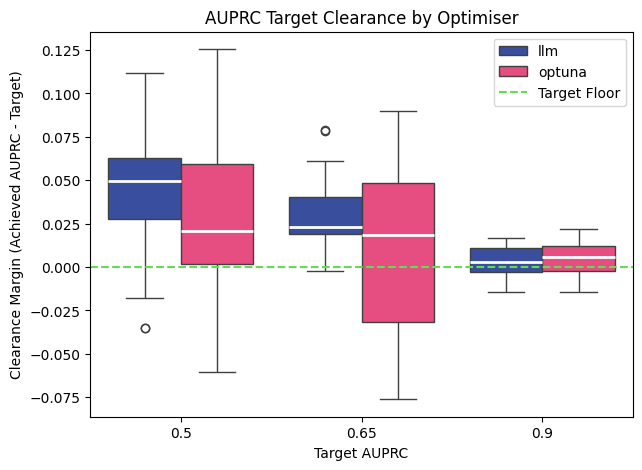

In [71]:
results_df["auprc_margin"] = results_df["auprc"] - results_df["target_auprc"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
  data=results_df,
  x="target_auprc",
  y="auprc_margin",
  hue="optimiser",
  palette=[CustPalette.primary, CustPalette.secondary],
  medianprops={'linewidth': 2,'color':'white'}
)

# Reference zero-error line
ax.axhline(0, color=CustPalette.green, linestyle="--", linewidth=1.5, label="Target Floor")

ax.set_xlabel("Target AUPRC")
ax.set_ylabel("Clearance Margin (Achieved AUPRC - Target)")
ax.set_title("AUPRC Target Clearance by Optimiser")
ax.legend()
plt.show()

## Target disparities

In [72]:
# Bias Application Convergence Rate
optuna_bias_conv = results_df.loc[optuna_mask, "bias_converged"].sum()
llm_bias_conv = results_df.loc[llm_mask, "bias_converged"].sum()

print(f"OPTUNA: Number of bias converged runs: {optuna_bias_conv} ({optuna_bias_conv / len(results_df[optuna_mask]) * 100:.2f}%)")
print(f"LLM: Number of bias converged runs: {llm_bias_conv} ({llm_bias_conv / len(results_df[llm_mask]) * 100:.2f}%)")

OPTUNA: Number of bias converged runs: 50.0 (52.08%)
LLM: Number of bias converged runs: 41.0 (42.71%)


In [75]:
results_df["recall_disp_error"] = (
    results_df["recall_disp"] - results_df["target_recall_disp"]
)
results_df["ppv_disp_error"] = (
    results_df["ppv_disp"] - results_df["target_ppv_disp"]
)

results_df["recall_in_tol"] = (
    results_df["recall_disp_error"].abs() <= results_df["disp_tolerance"]
)
results_df["ppv_in_tol"] = (
    results_df["ppv_disp_error"].abs() <= results_df["disp_tolerance"]
)

for opt in ["llm", "optuna"]:
  sub = results_df[results_df["optimiser"] == opt]
  print(f"\n==== {opt.upper()} DISPARITY TOLERANCE COMPLIANCE ====")

  for (target_disp, target_recall_disp, target_ppv_disp), group in sub.groupby(['target_disp', 'target_recall_disp', 'target_ppv_disp']):
    print(f"\n---TARGET DISPARITY: {target_disp.upper()}---")
    if target_disp == "recall" or target_disp == "both":
      print(f"Target Recall Disparity: {target_recall_disp}")
      print(
        f"Recall Disparity within ±tol: {group['recall_in_tol'].sum()}/{len(group)} ({group['recall_in_tol'].mean()*100:.2f}%)"
      )
    if target_disp == "ppv" or target_disp == "both":
      print(f"Target PPV Disparity: {target_recall_disp}")
      print(
        f"PPV Disparity within ±tol:    {group['ppv_in_tol'].sum()}/{len(group)} ({group['ppv_in_tol'].mean()*100:.2f}%)"
      )


==== LLM DISPARITY TOLERANCE COMPLIANCE ====

---TARGET DISPARITY: BOTH---
Target Recall Disparity: 0.15
Recall Disparity within ±tol: 2/12 (16.67%)
Target PPV Disparity: 0.15
PPV Disparity within ±tol:    3/12 (25.00%)

---TARGET DISPARITY: PPV---
Target PPV Disparity: 0.0
PPV Disparity within ±tol:    12/12 (100.00%)

---TARGET DISPARITY: PPV---
Target PPV Disparity: 0.0
PPV Disparity within ±tol:    11/18 (61.11%)

---TARGET DISPARITY: PPV---
Target PPV Disparity: 0.0
PPV Disparity within ±tol:    0/12 (0.00%)

---TARGET DISPARITY: RECALL---
Target Recall Disparity: 0.08
Recall Disparity within ±tol: 11/12 (91.67%)

---TARGET DISPARITY: RECALL---
Target Recall Disparity: 0.15
Recall Disparity within ±tol: 5/18 (27.78%)

---TARGET DISPARITY: RECALL---
Target Recall Disparity: 0.25
Recall Disparity within ±tol: 0/12 (0.00%)

==== OPTUNA DISPARITY TOLERANCE COMPLIANCE ====

---TARGET DISPARITY: BOTH---
Target Recall Disparity: 0.15
Recall Disparity within ±tol: 1/12 (8.33%)
Target PPV

In [77]:
def build_disparity_table(df):
  records = []
  group_cols = [
      'optimiser',
      'target_disp',
      'target_recall_disp',
      'target_ppv_disp',
  ]

  for (opt, t_disp, t_recall, t_ppv), group in df.groupby(group_cols):
    total = len(group)

    # Recall Disparity Compliance
    if t_disp in ['recall', 'both']:
      r_met = group['recall_in_tol'].sum()
      r_str = f'{r_met}/{total} ({r_met / total * 100:.1f}%)'
    else:
      r_str = '—'
      t_recall = '—'

    # PPV Disparity Compliance
    if t_disp in ['ppv', 'both']:
      p_met = group['ppv_in_tol'].sum()
      p_str = f'{p_met}/{total} ({p_met / total * 100:.1f}%)'
    else:
      p_str = '—'
      t_ppv = '—'

    records.append({
        'Optimiser': opt.upper(),
        'Target Mode': t_disp.upper(),
        'Target Recall': t_recall,
        'Recall In Tol': r_str,
        'Target PPV': t_ppv,
        'PPV In Tol': p_str,
        'Total Runs': total,
    })

  return pd.DataFrame(records)


disp_summary_df = build_disparity_table(results_df)
disp_summary_df

,Optimiser,Target Mode,Target Recall,Recall In Tol,Target PPV,PPV In Tol,Total Runs
0,LLM,BOTH,0.15,2/12 (16.7%),0.1,3/12 (25.0%),12
1,LLM,PPV,—,—,0.04,12/12 (100.0%),12
2,LLM,PPV,—,—,0.1,11/18 (61.1%),18
3,LLM,PPV,—,—,0.2,0/12 (0.0%),12
4,LLM,RECALL,0.08,11/12 (91.7%),—,—,12
5,LLM,RECALL,0.15,5/18 (27.8%),—,—,18
6,LLM,RECALL,0.25,0/12 (0.0%),—,—,12
7,OPTUNA,BOTH,0.15,1/12 (8.3%),0.1,4/12 (33.3%),12
8,OPTUNA,PPV,—,—,0.04,12/12 (100.0%),12
9,OPTUNA,PPV,—,—,0.1,16/18 (88.9%),18


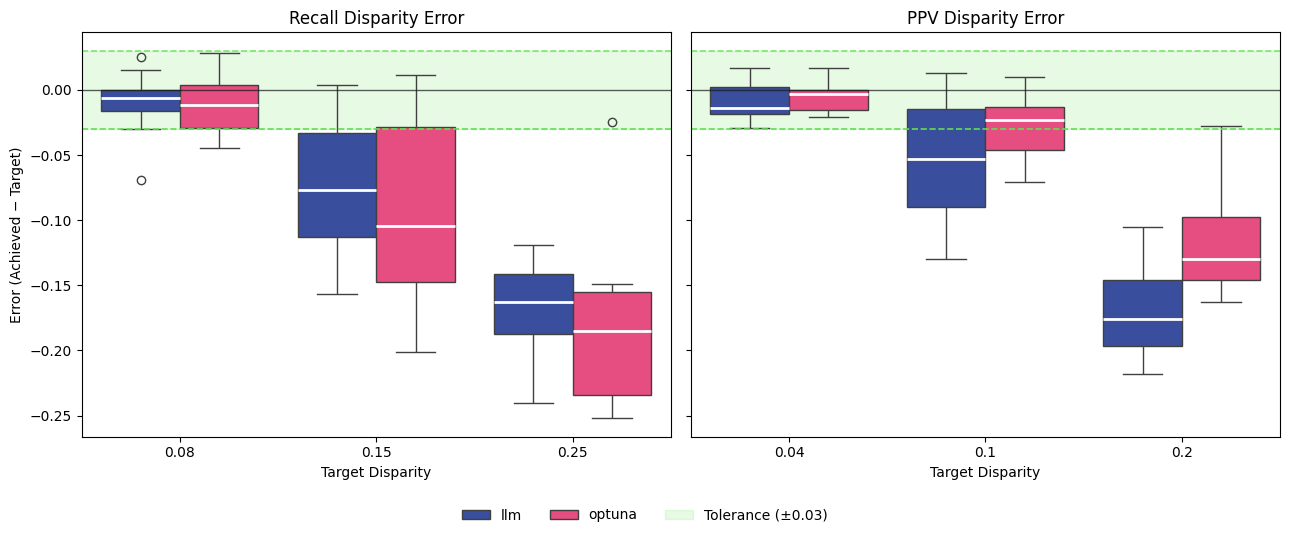

In [81]:
avg_tol = results_df["disp_tolerance"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

metrics = [
    (
        "target_recall_disp",
        "recall_disp_error",
        "Recall Disparity Error",
        axes[0],
    ),
    ("target_ppv_disp", "ppv_disp_error", "PPV Disparity Error", axes[1]),
]

for target_col, error_col, title, ax in metrics:
  plot_data = results_df[results_df[target_col] != 0.0]

  sns.boxplot(
      data=plot_data,
      x=target_col,
      y=error_col,
      hue="optimiser",
      palette=[CustPalette.primary, CustPalette.secondary],
      medianprops={"linewidth": 2, "color": "white"},
      ax=ax,
  )

  # Tolerance band & zero reference line
  ax.axhline(
      0, color=CustPalette.grey_dark, linestyle="-", linewidth=1, alpha=0.7
  )
  ax.axhspan(
      -avg_tol,
      avg_tol,
      color=CustPalette.green,
      alpha=0.15,
      label=f"Tolerance (±{avg_tol:.2f})",
  )
  ax.axhline(
      avg_tol,
      color=CustPalette.green,
      linestyle="--",
      linewidth=1.2,
      alpha=0.8,
  )
  ax.axhline(-avg_tol, color=CustPalette.green, linestyle="--", linewidth=1.2)

  ax.set_title(title)
  ax.set_xlabel("Target Disparity")
  ax.set_ylabel("Error (Achieved − Target)")

  # Remove subplot legend
  if ax.get_legend() is not None:
    ax.get_legend().remove()

# Extract unique handles/labels from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

# Place single unified horizontal legend below both plots
fig.legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=len(labels),
    frameon=False,
)

plt.tight_layout()
plt.show()

---

# Search Efficiency

## Retries summary by phase

In [83]:
# Summary statistics for trials, retries, and wall-clock time
efficiency_cols = ['raw_gen_trials', 'retry_count', 'wall_clock_sec']

efficiency_summary = (
    results_df.groupby('optimiser')[efficiency_cols]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(2)
)

efficiency_summary

raw_gen_trials                         retry_count               \
                    mean median   std  min   max        mean median   std   
optimiser                                                                   
llm                 0.25    0.0  0.60  0.0   3.0        6.71   10.0  4.04   
optuna              0.98    0.0  2.45  0.0  10.0       12.06   17.5  8.52   

                     wall_clock_sec                               
           min   max           mean median    std    min     max  
optimiser                                                         
llm        0.0  10.0          60.76  78.07  29.27  10.47  115.95  
optuna     0.0  20.0          63.89  89.22  37.33  10.23  120.66

## Cumulative completion rate by phase

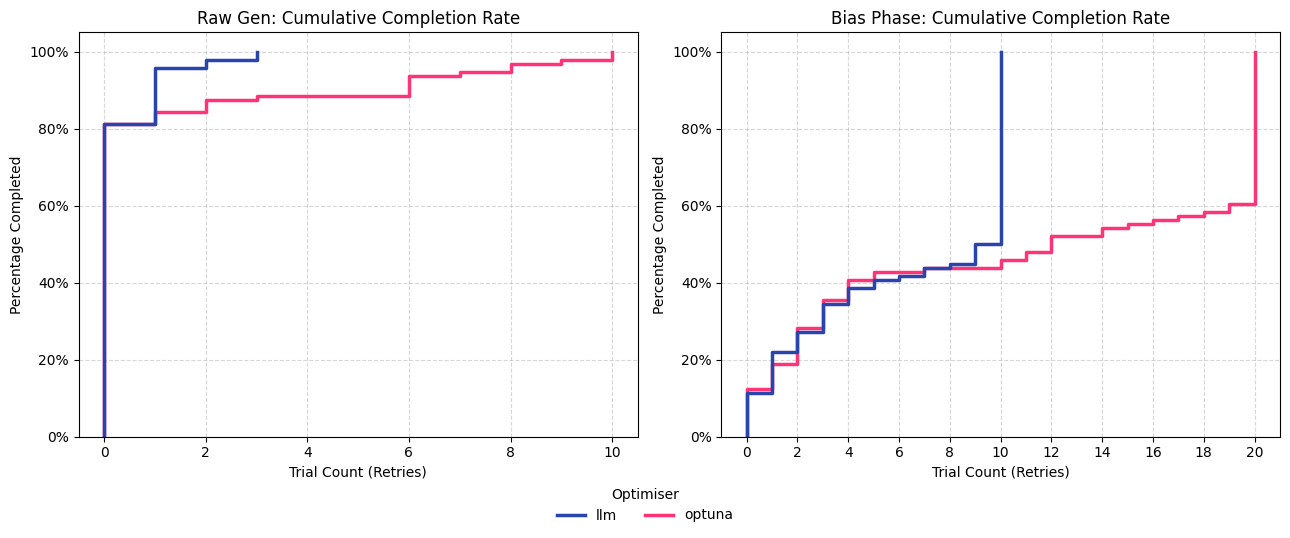

In [99]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, PercentFormatter
import seaborn as sns

results_df["bias_trials"] = (
    results_df["retry_count"] - results_df["raw_gen_trials"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Raw Generation ECDF
sns.ecdfplot(
    data=results_df,
    x="raw_gen_trials",
    hue="optimiser",
    palette=[CustPalette.primary, CustPalette.secondary],
    linewidth=2.5,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Raw Gen: Cumulative Completion Rate")
axes[0].set_xlabel("Trial Count (Retries)")
axes[0].set_ylabel("Percentage Completed")
axes[0].xaxis.set_major_locator(MultipleLocator(2))

# 2. Bias Phase ECDF
sns.ecdfplot(
    data=results_df,
    x="bias_trials",
    hue="optimiser",
    palette=[CustPalette.primary, CustPalette.secondary],
    linewidth=2.5,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Bias Phase: Cumulative Completion Rate")
axes[1].set_xlabel("Trial Count (Retries)")
axes[1].set_ylabel("Percentage Completed")
axes[1].xaxis.set_major_locator(MultipleLocator(2))

# Formatting for both subplots
for ax in axes:
  ax.yaxis.set_major_formatter(PercentFormatter(1.0))
  ax.set_ylim(0, 1.05)  # Slightly above 100% for visibility
  ax.grid(True, linestyle="--", alpha=0.5)

# Build explicit legend handles using the palette
legend_elements = [
    Line2D([0], [0], color=CustPalette.primary, lw=2.5, label="llm"),
    Line2D([0], [0], color=CustPalette.secondary, lw=2.5, label="optuna"),
]

fig.legend(
    handles=legend_elements,
    title="Optimiser",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False,
)

plt.tight_layout()
plt.show()

## Wall clock duration by Target Disparity

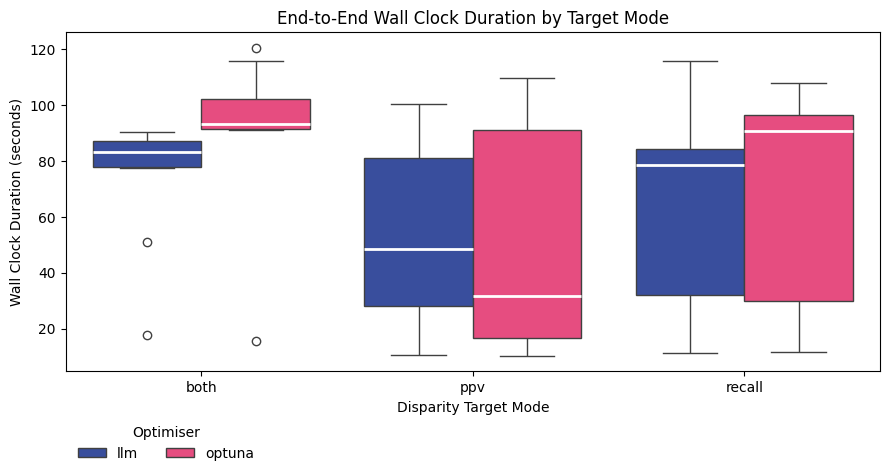

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=results_df,
    x='target_disp',
    y='wall_clock_sec',
    hue='optimiser',
    palette=[CustPalette.primary, CustPalette.secondary],
    medianprops={'linewidth': 2, 'color': 'white'},
    ax=ax,
)

ax.set_title('End-to-End Wall Clock Duration by Target Mode')
ax.set_xlabel('Disparity Target Mode')
ax.set_ylabel('Wall Clock Duration (seconds)')
ax.legend(
    title='Optimiser',
    loc="lower left", 
    bbox_to_anchor=(0, -0.3),
    ncol=2,
    frameon=False)

plt.tight_layout()
plt.show()

## LLM: Token consumption by target disparity

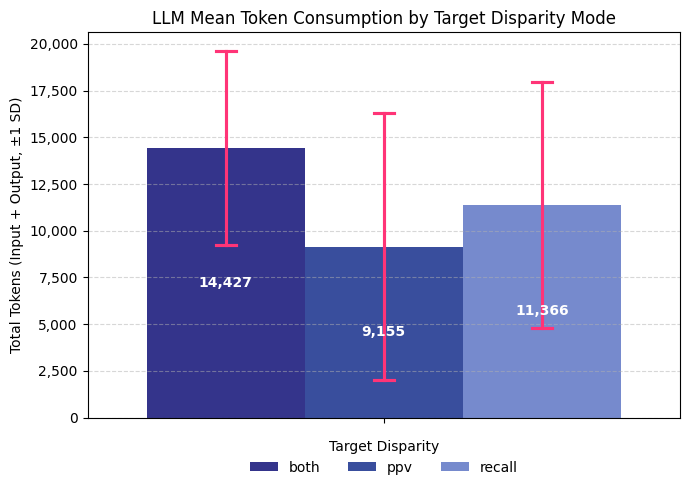

In [109]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Prepare LLM subset
llm_data = results_df[results_df['optimiser'] == 'llm'].copy()
llm_data['total_tokens'] = llm_data['input_tokens'] + llm_data['output_tokens']

fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(
  data=llm_data,
  hue='target_disp',
  y='total_tokens',
  palette=[CustPalette.primary_dark, CustPalette.primary, CustPalette.primary_med],
  estimator='mean',
  errorbar='sd',
  err_kws={'color':CustPalette.secondary},
  capsize=0.1,
  ax=ax,
)

# Label bar heights with exact mean token counts
for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
      f'{int(height):,}',
      (p.get_x() + p.get_width() / 2.0, height / 2.0),
      ha='center',
      va='center',
      color='white',
      fontweight='bold',
    )

ax.set_title('LLM Mean Token Consumption by Target Disparity Mode')
ax.set_xlabel('')
ax.set_ylabel('Total Tokens (Input + Output, ±1 SD)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(
  title="Target Disparity",
  loc="lower center", 
  bbox_to_anchor=(0.5, -0.18),
  ncol=3,
  frameon=False)

plt.tight_layout()
plt.show()